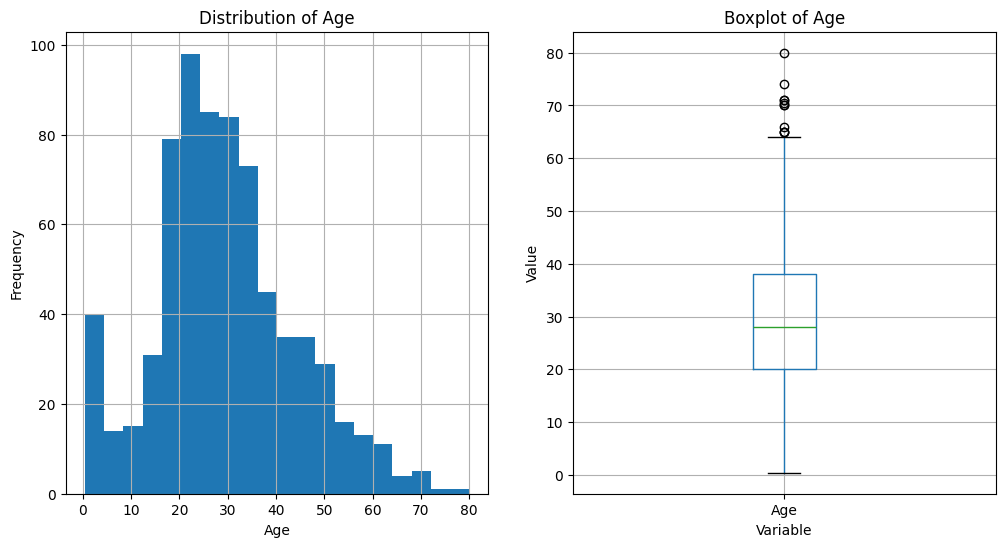

In [23]:
# In the Titanic dataset, analyze the mean, median, and mode of Passenger Age and plot a histogram and boxplot to examine the distribution and outliers.

import pandas as pd
import matplotlib.pyplot as plt

# Load the Titanic dataset
titanic_data = pd.read_csv('../datasets/Titanic-Dataset.csv')

# Calculate the mean, median, and mode of Passenger Age
mean_age = titanic_data['Age'].mean()
median_age = titanic_data['Age'].median()
mode_age = titanic_data['Age'].mode()[0]

# Plot a histogram and boxplot to examine the distribution and outliers
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
titanic_data['Age'].hist(bins=20)
plt.xlabel('Age')   
plt.ylabel('Frequency')
plt.title('Distribution of Age')

plt.subplot(1, 2, 2)
titanic_data.boxplot(column='Age')
plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Boxplot of Age')

plt.show()

Mean of Fare: 32.204207968574636
Median of Fare: 14.4542
Standard deviation of Fare: 49.6934285971809


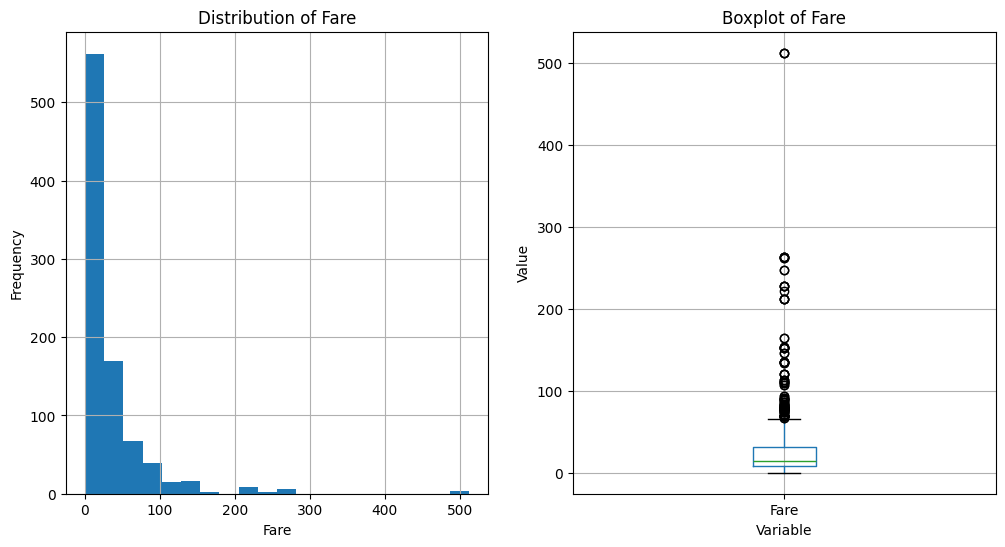

In [13]:
mean_fare = titanic_data['Fare'].mean()
median_fare = titanic_data['Fare'].median()
std_fare = titanic_data['Fare'].std()

print("Mean of Fare:", mean_fare)
print("Median of Fare:", median_fare)
print("Standard deviation of Fare:", std_fare)

# Plot a histogram and boxplot to identify outliers
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
titanic_data['Fare'].hist(bins=20)
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.title('Distribution of Fare')

plt.subplot(1, 2, 2)
titanic_data.boxplot(column='Fare')
plt.xlabel('Variable')
plt.ylabel('Value')
plt.title('Boxplot of Fare')

plt.show()

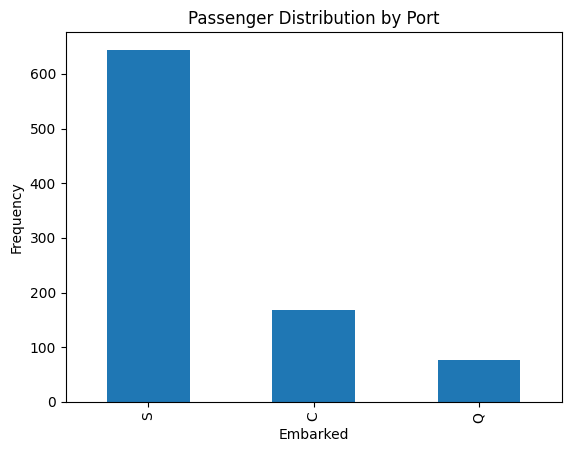

In [14]:
titanic_data['Embarked'].value_counts().plot(kind='bar')
plt.xlabel('Embarked')
plt.ylabel('Frequency')
plt.title('Passenger Distribution by Port')
plt.show()

C:\Users\alikh\AppData\Local\Temp\ipykernel_9368\2456576215.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)


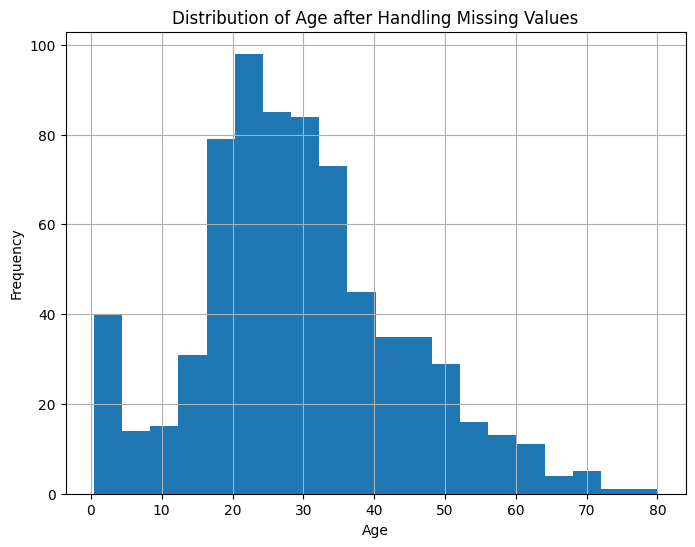

In [15]:
# Identify missing values in the Age column
missing_values = titanic_data['Age'].isnull().sum()

# Impute missing values using median
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)

# Plot a histogram to see the effect of handling null values
plt.figure(figsize=(8, 6))
titanic_data['Age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age after Handling Missing Values')
plt.show()

In [16]:

missing_values = titanic_data['Cabin'].isnull().sum()

# Calculate the percentage of missing data
total_data_points = len(titanic_data)
percentage_missing = (missing_values / total_data_points) * 100
if percentage_missing > 50:
    print("Percentage of missing data in Cabin column:", percentage_missing)
    # Drop the Cabin column
    titanic_data.drop(columns=['Cabin'], inplace=True)
    print("Cabin column has been dropped.")
else:
    print("Percentage of missing data in Cabin column:", percentage_missing)
    # Fill missing values with "Unknown"
    titanic_data['Cabin'].fillna('Unknown', inplace=True)


Percentage of missing data in Cabin column: 77.10437710437711
Cabin column has been dropped.


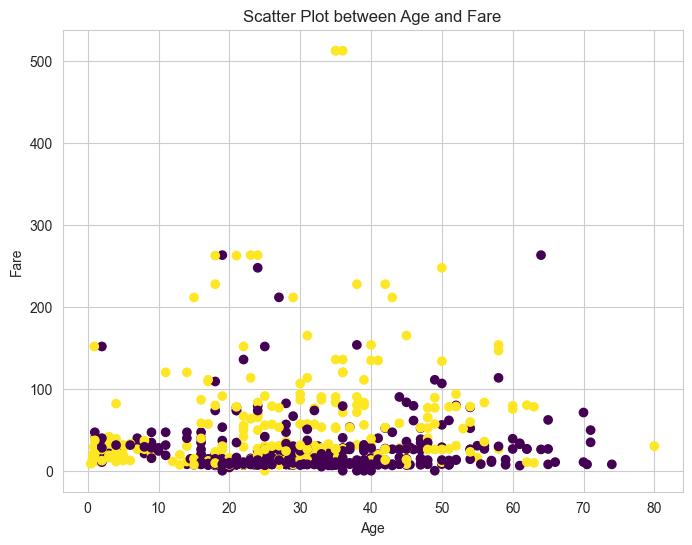

Correlation between Age and Fare: 0.09606669176903894


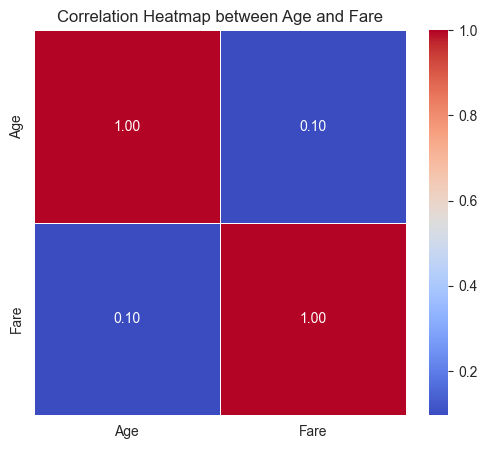

Outliers in the scatter plot:
Empty DataFrame
Columns: [PassengerId, Survived, Pclass, Name, Sex, Age, SibSp, Parch, Ticket, Fare, Cabin, Embarked]
Index: []


In [34]:
import seaborn as sns
# Plot a scatter plot between Age and Fare
plt.figure(figsize=(8, 6))

plt.scatter(titanic_data['Age'], titanic_data['Fare'], c=titanic_data['Survived'], cmap='viridis')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.title('Scatter Plot between Age and Fare')
plt.show()
# Calculate the correlation between Age and Fare
correlation = titanic_data['Age'].corr(titanic_data['Fare'])
print("Correlation between Age and Fare:", correlation)

plt.figure(figsize=(6, 5))

correlation_matrix = titanic_data[['Age', 'Fare']].corr()

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=0.5)

plt.title('Correlation Heatmap between Age and Fare')
plt.show()
# Identify outliers in the scatter plot
outliers = titanic_data[(titanic_data['Age'] > 50) & (titanic_data['Fare'] > 500)]
print("Outliers in the scatter plot:")
print(outliers)

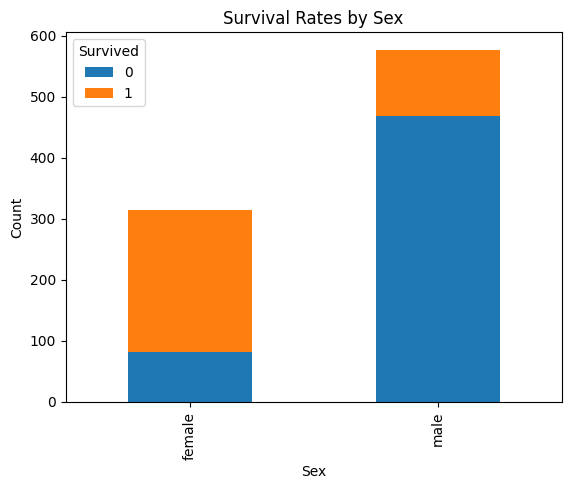

In [25]:

contingency_table = pd.crosstab(titanic_data['Sex'], titanic_data['Survived'])
contingency_table.plot(kind='bar', stacked=True)
plt.xlabel('Sex')
plt.ylabel('Count')
plt.title('Survival Rates by Sex')
plt.show()

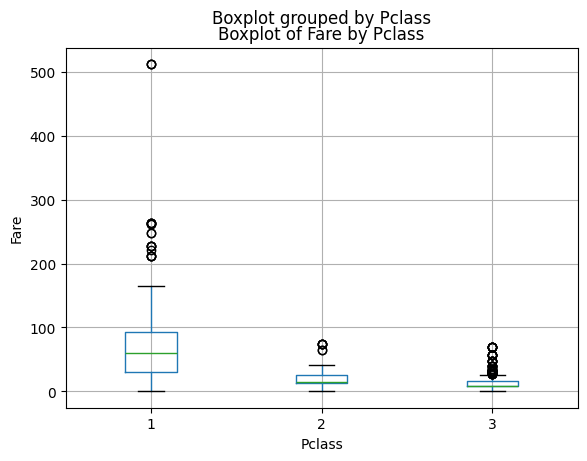

In [26]:
# Plot a boxplot of Fare for each Pclass
titanic_data.boxplot(column='Fare', by='Pclass')
plt.xlabel('Pclass')
plt.ylabel('Fare')
plt.title('Boxplot of Fare by Pclass')
plt.show()

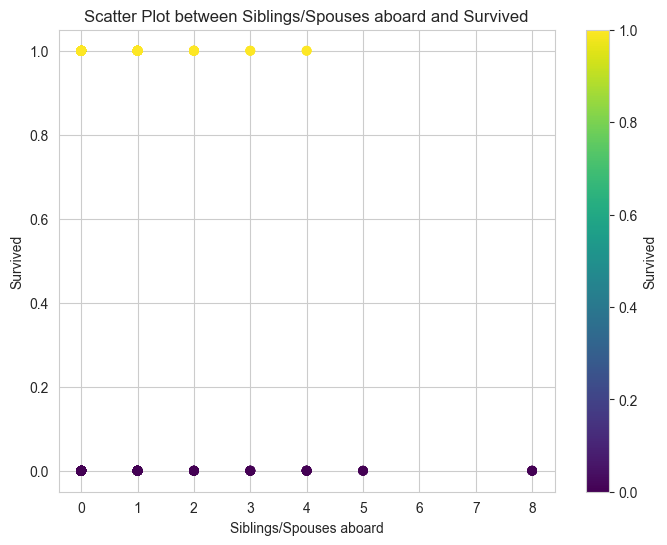

Correlation between Siblings/Spouses aboard and Survived: -0.03532249888573557


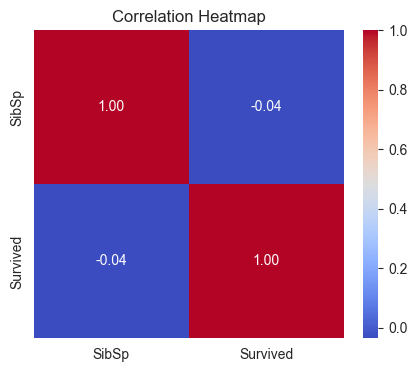

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot
plt.figure(figsize=(8, 6))
plt.scatter(titanic_data['SibSp'], titanic_data['Survived'], 
            c=titanic_data['Survived'], cmap='viridis')
plt.xlabel('Siblings/Spouses aboard')
plt.ylabel('Survived')
plt.title('Scatter Plot between Siblings/Spouses aboard and Survived')
plt.colorbar(label='Survived')
plt.show()

# Calculate correlation
correlation = titanic_data['SibSp'].corr(titanic_data['Survived'])
print("Correlation between Siblings/Spouses aboard and Survived:", correlation)

# Correlation Heatmap
plt.figure(figsize=(5, 4))
sns.heatmap(titanic_data[['SibSp', 'Survived']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

C:\Users\alikh\AppData\Local\Temp\ipykernel_9368\514074183.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)


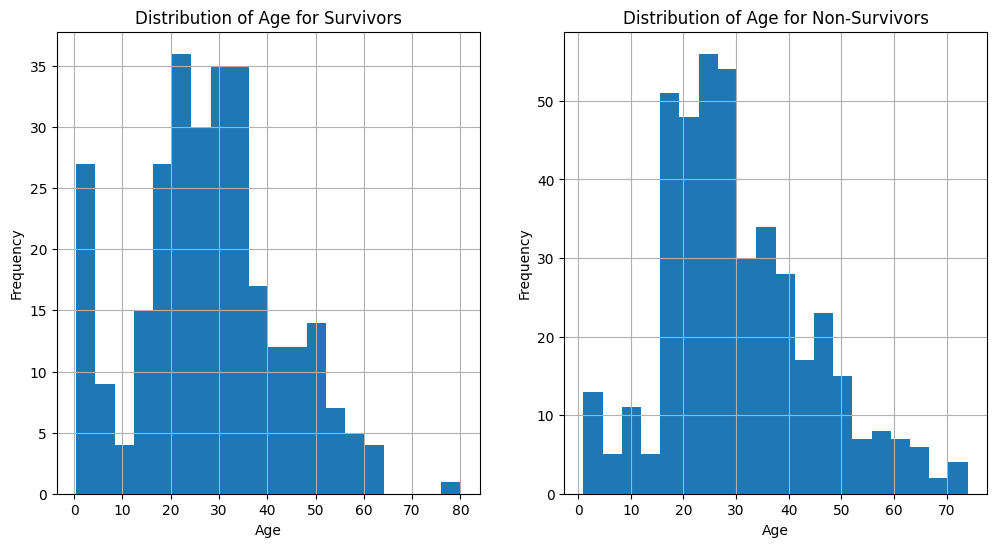

Mean of Age for Survivors: 28.343689655172415
Median of Age for Survivors: 28.0
Mean of Age for Non-Survivors: 30.62617924528302
Median of Age for Non-Survivors: 28.0


In [29]:
# Handle missing Age values
titanic_data['Age'].fillna(titanic_data['Age'].median(), inplace=True)

# Plot the Age distribution for survivors and non-survivors
survivors = titanic_data[titanic_data['Survived'] == 1]
non_survivors = titanic_data[titanic_data['Survived'] == 0]

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
survivors['Age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age for Survivors')

plt.subplot(1, 2, 2)
non_survivors['Age'].hist(bins=20)
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.title('Distribution of Age for Non-Survivors')

plt.show()

# Calculate the mean and median of the Age column for survivors and non-survivors
survivors_mean = survivors['Age'].mean()
survivors_median = survivors['Age'].median()
non_survivors_mean = non_survivors['Age'].mean()
non_survivors_median = non_survivors['Age'].median()

print("Mean of Age for Survivors:", survivors_mean)
print("Median of Age for Survivors:", survivors_median)
print("Mean of Age for Non-Survivors:", non_survivors_mean)
print("Median of Age for Non-Survivors:", non_survivors_median)


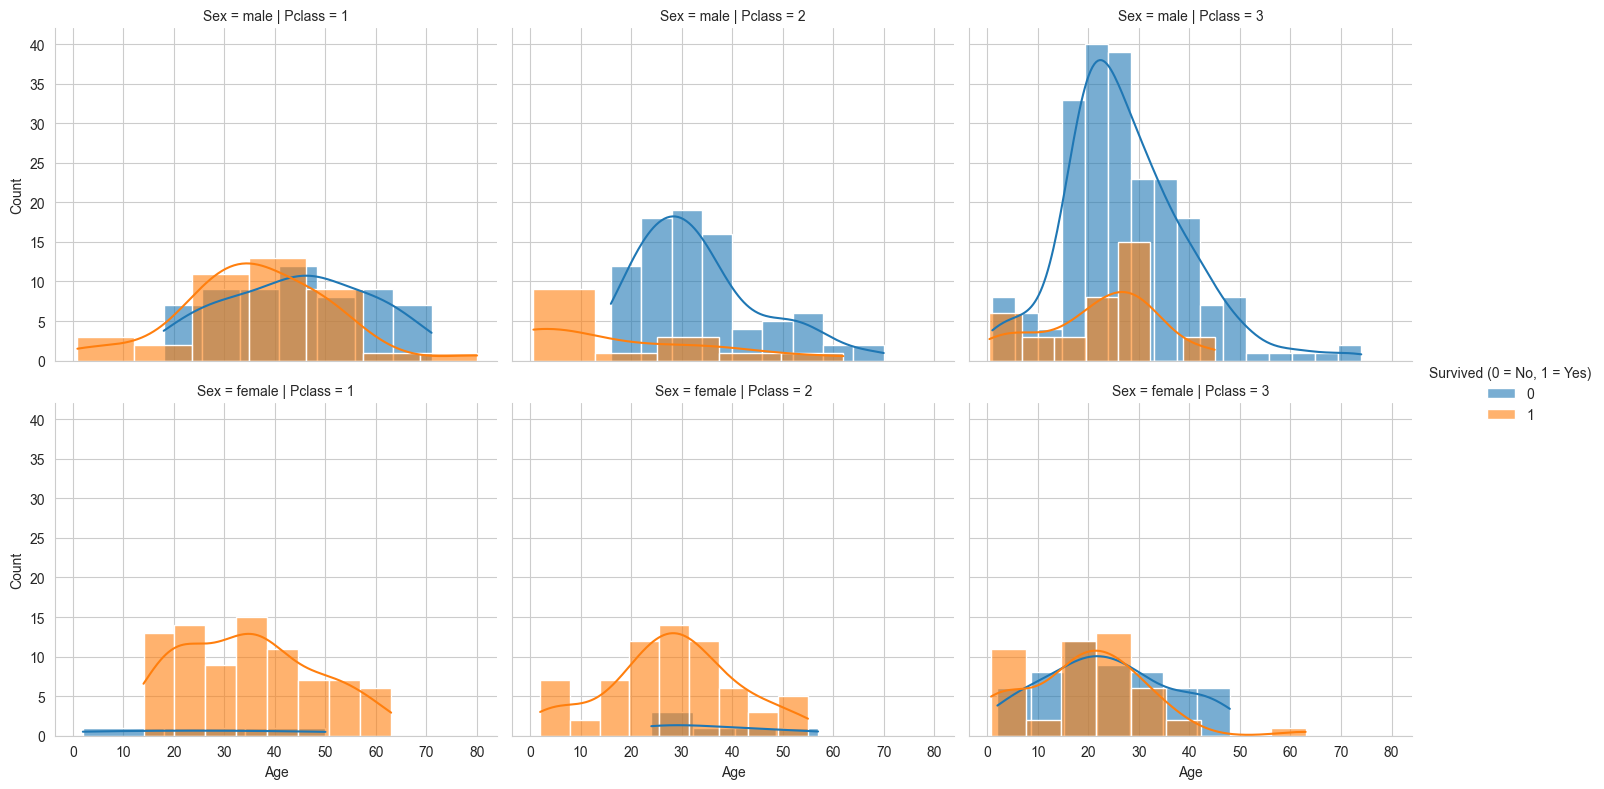

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Drop missing Age values
df = titanic_data.dropna(subset=['Age'])

# Set style
sns.set_style("whitegrid")

# Facet Grid
g = sns.FacetGrid(
    df,
    row="Sex",
    col="Pclass",
    hue="Survived",
    height=4,
    aspect=1.2
)

g.map(sns.histplot, "Age", kde=True, alpha=0.6)
g.add_legend(title="Survived (0 = No, 1 = Yes)")

plt.show()

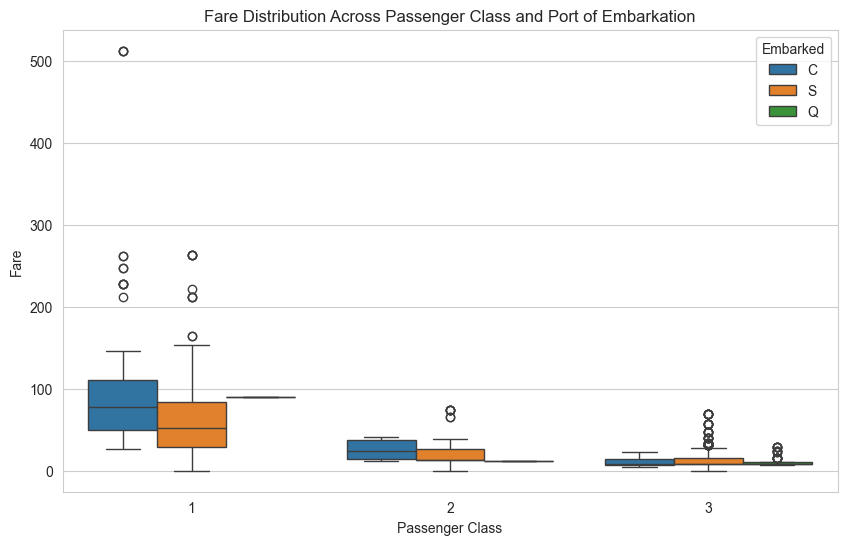

In [32]:
sns.set_style("whitegrid")

plt.figure(figsize=(10,6))

sns.boxplot(
    data=titanic_data,
    x="Pclass",
    y="Fare",
    hue="Embarked"
)

plt.title("Fare Distribution Across Passenger Class and Port of Embarkation")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.legend(title="Embarked")
plt.show()